# Session 6 Step 2: Static vs Dynamic Audit of Run A and Run C

The Session 5 outcome was TRIVIAL-dominant (Run A; PR=1.025, r2(z->c)=0.779) and
SPREAD_TRIVIAL-novel (Run C; PR=17.46, r2(z->c)=0.887). This notebook decomposes
each encoder's latent into a static (case-mean) component and a dynamic (within-
encounter) component, then quantifies how much of the variance and how much of
the c/phase information lives in each component.

Definitions:

- `z_all`        : `(N_enc, T, d)` encoder outputs across all Test A encounters
- `z_case_mean`  : `(N_cases, d)` mean of z over time and encounters per case
- `z_dyn`        : `z_all - z_case_mean[case_of_enc]` (within-case dynamic part)

Metrics:

- `PR_all`           : participation ratio over all (enc, T) latents
- `PR_case_mean`     : participation ratio over case means
- `PR_within_case`   : mean over cases of PR(z_dyn restricted to that case)
- `r2(z -> c)`       : linear probe r2 from z_all to (G, D, Y)
- `r2(z_dyn -> c)`   : same, on the dynamic part
- `r2(z -> phase)`   : linear probe r2 from z_all to frame-index-within-encounter
- `r2(z_dyn -> phase)`: same, on the dynamic part

Read these alongside the Session 6 plan (`SESSION6_FACTORIAL_DIAGNOSTIC.md` Step
2) and the Run A / Run C TRIVIAL / SPREAD_TRIVIAL diagnoses in HANDOFF D27.


In [1]:
from __future__ import annotations

import json
import os
import sys
from collections import defaultdict
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from sklearn.decomposition import PCA

REPO = Path.cwd().resolve()
while REPO.name and not (REPO / 'configs' / 'splits').exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
print('repo root:', REPO)

from src.data.episode_dataset import EpisodeDataset
from src.models.encoder import HybridCNNViTEncoder
from src.training.diagnostics import linear_probe_r2, participation_ratio

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

D = 32
SMOKE_CASES = yaml.safe_load(open(REPO / 'configs' / 'cases' / 'smoke_5cases.yaml'))['cases']
print(f'smoke cases ({len(SMOKE_CASES)}):', SMOKE_CASES)


repo root: /home/carlos/GUST-JEPA


device: cuda
smoke cases (5): ['Baseline', 'G+3.00_D0.50_Y+0.40', 'G-3.00_D1.00_Y-0.20', 'G+1.00_D1.50_Y+0.20', 'G+1.00_D1.00_Y-0.20']


## Section 1: Load Run A and Run C checkpoints and build encoders

In [2]:
RUN_DIRS = {
    'Run A (SIGReg + BN)': REPO / 'outputs' / 'runs' / 'smoke5k' / 'run_a_sigreg_bn',
    'Run C (VICReg + BN)': REPO / 'outputs' / 'runs' / 'smoke5k' / 'run_c_vicreg_bn',
}
CKPT_NAME = 'checkpoint_iter005000.pt'


def load_encoder(run_dir: Path) -> tuple[HybridCNNViTEncoder, dict]:
    blob = torch.load(run_dir / CKPT_NAME, map_location='cpu', weights_only=False)
    args = blob['args']
    enc = HybridCNNViTEncoder(
        latent_dim=int(args['d']),
        projection_norm=args.get('projection_norm', 'batchnorm'),
    )
    state = {k.removeprefix('encoder.'): v for k, v in blob['jepa_state_dict'].items()
             if k.startswith('encoder.')}
    missing, unexpected = enc.load_state_dict(state, strict=False)
    enc.eval().to(device)
    info = {
        'iteration': blob['iteration'],
        'projection_norm': args.get('projection_norm', 'batchnorm'),
        'anticollapse': args.get('anticollapse', 'sigreg'),
        'cases': args['cases'],
        'missing_keys': list(missing),
        'unexpected_keys': list(unexpected),
    }
    return enc, info


encoders = {}
for label, run_dir in RUN_DIRS.items():
    enc, info = load_encoder(run_dir)
    encoders[label] = enc
    print(label)
    print(f'  iter={info["iteration"]} proj={info["projection_norm"]} anti={info["anticollapse"]}')
    print(f'  missing={len(info["missing_keys"])} unexpected={len(info["unexpected_keys"])}')


Run A (SIGReg + BN)
  iter=5000 proj=batchnorm anti=sigreg
  missing=0 unexpected=0


Run C (VICReg + BN)
  iter=5000 proj=batchnorm anti=vicreg
  missing=0 unexpected=0


## Section 2: Encode all Test A samples (full encounter, deterministic order)

We load Test A encounters for the 5 smoke cases at the full encounter length
(120 frames) so the per-frame phase index is meaningful. The encoder is
applied frame-by-frame so we get one z per frame per encounter.

In [3]:
def gather_test_a_encounters() -> list[dict]:
    """Return one dict per Test A encounter in the smoke 5-case subset.

    Reads the cache directly so we get the full 120-frame omega field (the
    standard EpisodeDataset emits a sub-trajectory).
    """
    with open(REPO / 'configs' / 'splits' / 'split_v1.json') as f:
        split = json.load(f)
    PREVENT = Path(os.environ.get('PREVENT_ROOT', '/home/carlos/PREVENT'))
    CACHE = Path(os.environ.get('VORTEX_JEPA_CACHE', PREVENT / 'data' / 'processed' / 'vortex-jepa'))
    encs = []
    for cid in SMOKE_CASES:
        case = split['cases'][cid]
        for k in case['test_a_encounter_indices']:
            path = CACHE / 'v1' / cid / f'encounter_{k:02d}.h5'
            with h5py.File(path, 'r') as g:
                encs.append({
                    'case_id': cid,
                    'encounter_index': int(k),
                    'omega_z': np.asarray(g['omega_z'], dtype=np.float32),
                    'C_L': np.asarray(g['C_L'], dtype=np.float32),
                    'G': float(g.attrs['G']),
                    'D': float(g.attrs['D']),
                    'Y': float(g.attrs['Y']),
                })
    return encs


ENCS = gather_test_a_encounters()
T_full = ENCS[0]['omega_z'].shape[0]
N_enc = len(ENCS)
print(f'{N_enc} Test A encounters from {len(set(e["case_id"] for e in ENCS))} smoke cases; T={T_full}')


def encode_all(enc: HybridCNNViTEncoder) -> np.ndarray:
    """Run the encoder over every (encounter, frame) and return (N_enc, T, d)."""
    out = np.empty((N_enc, T_full, D), dtype=np.float32)
    with torch.no_grad():
        for i, ent in enumerate(ENCS):
            x = torch.from_numpy(ent['omega_z']).unsqueeze(1).to(device)  # (T, 1, H, W)
            with torch.autocast(device_type=device.type, dtype=torch.bfloat16, enabled=device.type == 'cuda'):
                z = enc(x.unsqueeze(0))  # add a B=1 dim; (1, T, d)
            out[i] = z.squeeze(0).float().cpu().numpy()
    return out


Z = {label: encode_all(enc) for label, enc in encoders.items()}
for label, z in Z.items():
    print(f'{label}: z shape={z.shape}  finite={np.isfinite(z).all()}  '
          f'min={z.min():+.3f}  max={z.max():+.3f}')


6 Test A encounters from 5 smoke cases; T=120


Run A (SIGReg + BN): z shape=(6, 120, 32)  finite=True  min=-1.859  max=+1.852
Run C (VICReg + BN): z shape=(6, 120, 32)  finite=True  min=-3.172  max=+3.125


## Section 3: Static-dynamic decomposition

For each encounter, the case identity (and thus its c) is known. We compute
the per-case mean over (encounters, frames) and subtract it from every frame
of every encounter in that case to obtain `z_dyn`.

In [4]:
case_of_enc = np.array([e['case_id'] for e in ENCS])
G_of_enc = np.array([e['G'] for e in ENCS], dtype=np.float32)
D_of_enc = np.array([e['D'] for e in ENCS], dtype=np.float32)
Y_of_enc = np.array([e['Y'] for e in ENCS], dtype=np.float32)
c_of_enc = np.stack([G_of_enc, D_of_enc, Y_of_enc], axis=1)


def split_static_dynamic(z_all: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Return (z_case_mean (N_cases, d), z_dyn (N_enc, T, d))."""
    cases = sorted(set(case_of_enc))
    means = []
    for cid in cases:
        mask = case_of_enc == cid
        means.append(z_all[mask].reshape(-1, D).mean(axis=0))
    z_case_mean = np.stack(means, axis=0)
    cid_to_idx = {cid: i for i, cid in enumerate(cases)}
    z_dyn = z_all.copy()
    for i in range(z_all.shape[0]):
        z_dyn[i] -= z_case_mean[cid_to_idx[case_of_enc[i]]]
    return z_case_mean, z_dyn


Z_case_mean, Z_dyn = {}, {}
for label, z in Z.items():
    cm, zd = split_static_dynamic(z)
    Z_case_mean[label], Z_dyn[label] = cm, zd
    print(f'{label}: z_case_mean shape={cm.shape}  '
          f'z_dyn shape={zd.shape}  '
          f'||z_dyn|| / ||z|| = '
          f'{np.linalg.norm(zd) / np.linalg.norm(z):.3f}')


Run A (SIGReg + BN): z_case_mean shape=(5, 32)  z_dyn shape=(6, 120, 32)  ||z_dyn|| / ||z|| = 0.102
Run C (VICReg + BN): z_case_mean shape=(5, 32)  z_dyn shape=(6, 120, 32)  ||z_dyn|| / ||z|| = 0.828


## Section 4: Eight metrics, side-by-side table

`participation_ratio` is from `src.training.diagnostics` (the same function used
in W&B during training). `linear_probe_r2` returns the same r2 surface the
diagnostics callback computes.

In [5]:
def pr_of(arr_2d: np.ndarray) -> float:
    """Wrapper around src.training.diagnostics.participation_ratio."""
    t = torch.from_numpy(arr_2d.astype(np.float32))
    return float(participation_ratio(t))


def probe_r2(z_2d: np.ndarray, y_2d: np.ndarray, seed: int = 0) -> float:
    """Wrapper around src.training.diagnostics.linear_probe_r2."""
    n = z_2d.shape[0]
    rng = np.random.default_rng(seed)
    perm = rng.permutation(n)
    nfit = max(2, int(0.75 * n))
    fit, ev = perm[:nfit], perm[nfit:]
    if ev.size < 2:
        fit, ev = perm[:n // 2], perm[n // 2:]
    z_t = torch.from_numpy(z_2d.astype(np.float32))
    y_t = torch.from_numpy(y_2d.astype(np.float32))
    fit_t = torch.from_numpy(fit)
    ev_t = torch.from_numpy(ev)
    r2 = linear_probe_r2(z_t, y_t, fit_t, ev_t)
    if isinstance(r2, dict):
        return float(r2.get('r2_overall', float('nan')))
    return float(r2)


def metrics_for(label: str) -> dict:
    z_all = Z[label]
    z_cm = Z_case_mean[label]
    z_dyn = Z_dyn[label]
    z_flat = z_all.reshape(-1, D)
    z_dyn_flat = z_dyn.reshape(-1, D)

    pr_all = pr_of(z_flat)
    pr_cm = pr_of(z_cm)
    pr_within = float(np.mean([
        pr_of(z_dyn[case_of_enc == cid].reshape(-1, D))
        for cid in sorted(set(case_of_enc))
    ]))

    c_rep = np.repeat(c_of_enc, T_full, axis=0)
    r2_z_c = probe_r2(z_flat, c_rep)
    r2_zd_c = probe_r2(z_dyn_flat, c_rep)

    phase = np.tile(np.arange(T_full, dtype=np.float32), N_enc)[:, None]
    r2_z_phase = probe_r2(z_flat, phase)
    r2_zd_phase = probe_r2(z_dyn_flat, phase)

    return {
        'PR_all': pr_all,
        'PR_case_mean': pr_cm,
        'PR_within_case': pr_within,
        'r2_z_to_c': r2_z_c,
        'r2_z_dyn_to_c': r2_zd_c,
        'r2_z_to_phase': r2_z_phase,
        'r2_z_dyn_to_phase': r2_zd_phase,
        'frac_dyn_norm': float(np.linalg.norm(z_dyn) / np.linalg.norm(z_all)),
    }


rows = []
for label in Z:
    rows.append({'run': label, **metrics_for(label)})
df = pd.DataFrame(rows).set_index('run')
df.round(3)


,PR_all,PR_case_mean,PR_within_case,r2_z_to_c,r2_z_dyn_to_c,r2_z_to_phase,r2_z_dyn_to_phase,frac_dyn_norm
run,,,,,,,,
Run A (SIGReg + BN),1.022,1.005,2.247,0.732,-0.166,0.129,0.131,0.102
Run C (VICReg + BN),27.005,4.617,8.246,0.879,-0.171,0.248,0.494,0.828


## Section 5: Side-by-side bar chart

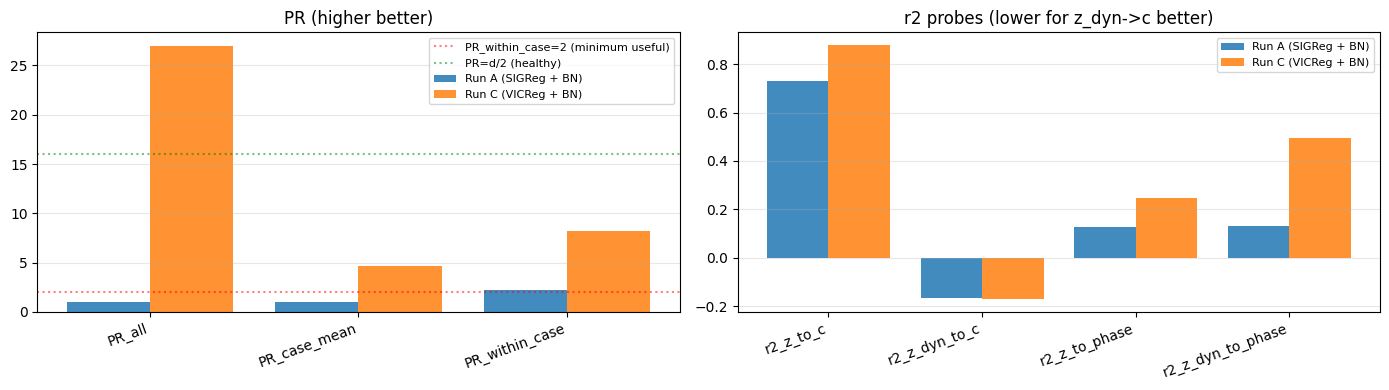

In [6]:
metric_keys = ['PR_all', 'PR_case_mean', 'PR_within_case',
               'r2_z_to_c', 'r2_z_dyn_to_c', 'r2_z_to_phase', 'r2_z_dyn_to_phase']
metric_axes = {
    'PR (higher better)': ['PR_all', 'PR_case_mean', 'PR_within_case'],
    'r2 probes (lower for z_dyn->c better)': ['r2_z_to_c', 'r2_z_dyn_to_c', 'r2_z_to_phase', 'r2_z_dyn_to_phase'],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = {'Run A (SIGReg + BN)': 'tab:blue', 'Run C (VICReg + BN)': 'tab:orange'}
for ax, (title, keys) in zip(axes, metric_axes.items()):
    x = np.arange(len(keys))
    w = 0.4
    for i, label in enumerate(df.index):
        ax.bar(x + (i - 0.5) * w, [df.loc[label, k] for k in keys], width=w,
               label=label, color=colors.get(label, None), alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(keys, rotation=20, ha='right')
    ax.set_title(title)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(fontsize=8)
# Mark a reference PR_within_case threshold (>=2 is the lower bound for "useful dynamic spread")
axes[0].axhline(2.0, color='red', linestyle=':', alpha=0.5, label='PR_within_case=2 (minimum useful)')
axes[0].axhline(0.5 * D, color='green', linestyle=':', alpha=0.5, label='PR=d/2 (healthy)')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


## Section 6: PCA visualizations

Two scatter plots per run: the first colored by case identity (effectively c
because c is constant per case), the second colored by frame-index-within-
encounter. A clean SPREAD_TRIVIAL pattern shows tight per-case clusters in the
left panel and no phase structure in the right panel.

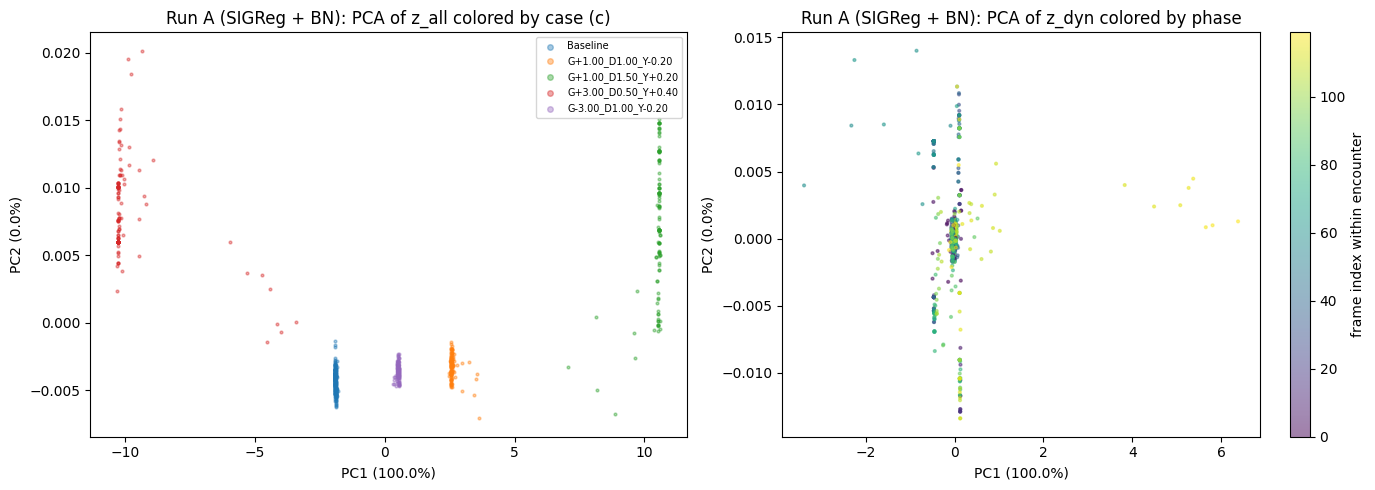

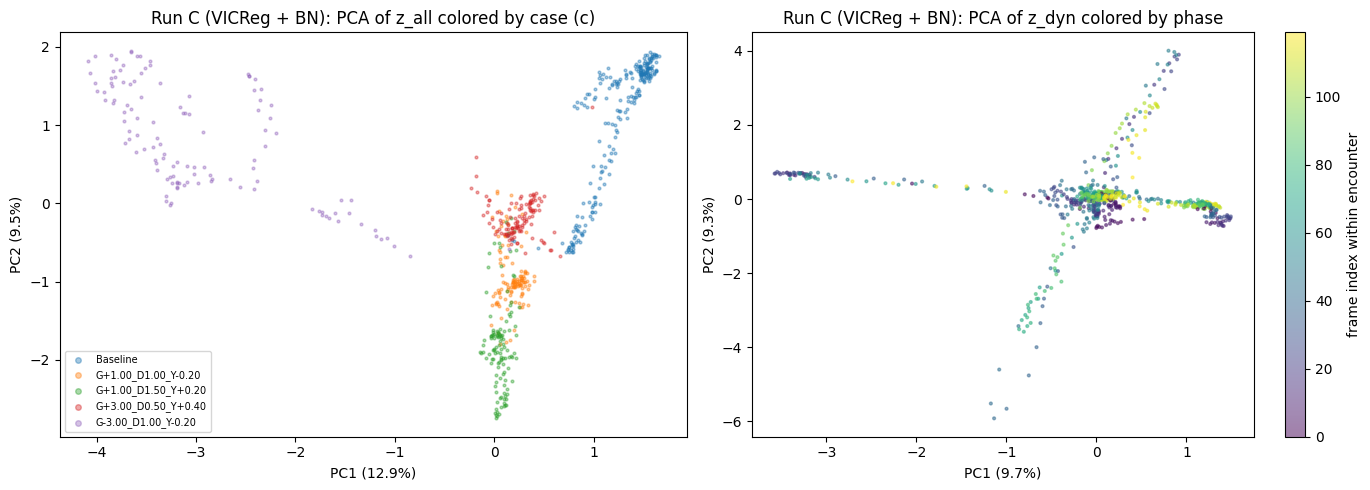

In [7]:
def make_pca_plot(label: str) -> None:
    z_all = Z[label]
    z_dyn = Z_dyn[label]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    pca_full = PCA(n_components=2).fit(z_all.reshape(-1, D))
    pts_full = pca_full.transform(z_all.reshape(-1, D))
    case_ids = np.repeat(case_of_enc, T_full)
    for cid in sorted(set(case_ids)):
        m = case_ids == cid
        axes[0].scatter(pts_full[m, 0], pts_full[m, 1], s=4, alpha=0.4, label=cid)
    axes[0].set_title(f'{label}: PCA of z_all colored by case (c)')
    axes[0].legend(fontsize=7, markerscale=2, loc='best')
    axes[0].set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)')
    axes[0].set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)')

    pca_dyn = PCA(n_components=2).fit(z_dyn.reshape(-1, D))
    pts_dyn = pca_dyn.transform(z_dyn.reshape(-1, D))
    phase = np.tile(np.arange(T_full), N_enc)
    sc = axes[1].scatter(pts_dyn[:, 0], pts_dyn[:, 1], c=phase, s=4, alpha=0.5, cmap='viridis')
    plt.colorbar(sc, ax=axes[1], label='frame index within encounter')
    axes[1].set_title(f'{label}: PCA of z_dyn colored by phase')
    axes[1].set_xlabel(f'PC1 ({pca_dyn.explained_variance_ratio_[0]*100:.1f}%)')
    axes[1].set_ylabel(f'PC2 ({pca_dyn.explained_variance_ratio_[1]*100:.1f}%)')
    plt.tight_layout()
    plt.show()


for label in Z:
    make_pca_plot(label)


## Section 7: Interpretation summary

The decision matrix from `SESSION6_FACTORIAL_DIAGNOSTIC.md` Step 2:

- `PR_within_case < 2`              -> encoder compressed all temporal variation into the case mean (no dynamic signal)
- `r2(z_dyn -> phase) > 0.5`        -> dynamic part captures useful within-encounter structure
- `r2(z_dyn -> c) > 0.5`            -> "dynamic" still leaks c (SPREAD_TRIVIAL signature)

Run A baseline expectation: TRIVIAL — PR_all near 1, all probes near 0.7 to 0.9
because the entire latent collapses onto a 1D axis that happens to correlate
with c. The within-case PR may still be very small.

Run C expectation: SPREAD_TRIVIAL — PR_all around 17, PR_within_case still low
(say 2 to 4), r2(z_dyn -> c) still moderate (around 0.5), r2(z_dyn -> phase)
near zero. The encoder uses its capacity to memorize cases, not dynamics.


In [8]:
summary_lines = []
for label, row in df.iterrows():
    msgs = []
    if row['PR_within_case'] < 2:
        msgs.append('within-case PR is below the useful-dynamics threshold (<2)')
    if row['r2_z_dyn_to_phase'] > 0.5:
        msgs.append('z_dyn carries usable phase information (r2 > 0.5)')
    else:
        msgs.append(f'z_dyn -> phase r2 only {row["r2_z_dyn_to_phase"]:.2f}')
    if row['r2_z_dyn_to_c'] > 0.5:
        msgs.append(f'z_dyn still leaks c (r2 {row["r2_z_dyn_to_c"]:.2f})  -- SPREAD_TRIVIAL signature')
    summary_lines.append(f'{label}: ' + '; '.join(msgs))
print('\n'.join(summary_lines))


Run A (SIGReg + BN): z_dyn -> phase r2 only 0.13
Run C (VICReg + BN): z_dyn -> phase r2 only 0.49
